# Sequential Quadratic Programming (SQP)

**Sequential Quadratic Programming** is one of the most powerful and widely-used algorithms for
nonlinear programming. The idea is elegant: at each iteration, approximate the NLP with a **Quadratic
Program (QP)** — a problem with a quadratic objective and linear constraints — and solve it exactly.

This notebook implements a complete SQP solver from scratch, step by step.

**Prerequisites:** Notebooks 01–04 (NLP intro, unconstrained methods, KKT conditions, penalty methods).

**Series:** Notebook 5 of 5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve as linalg_solve
from scipy.optimize import minimize

plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

## 1. The SQP Idea

Given the NLP:
$$\min_x f(x) \quad \text{s.t.} \quad g_{eq}(x) = 0, \quad g_{ineq}(x) \le 0$$

At the current point $x_k$ with multipliers $y_k$, form the **QP subproblem**:

$$\min_d \; \frac{1}{2} d^T B_k d + \nabla f(x_k)^T d$$
$$\text{s.t.} \quad J_{eq}(x_k) d + g_{eq}(x_k) = 0$$
$$J_{ineq}(x_k) d + g_{ineq}(x_k) \le 0$$

where:
- $B_k \approx \nabla^2_{xx} L(x_k, y_k)$ is a positive definite approximation of the Lagrangian Hessian
- $J = \nabla g$ is the constraint Jacobian

The QP subproblem is a **linearization of the constraints** combined with a **quadratic model of
the objective (via the Lagrangian)** — it captures the local geometry of the NLP exactly to second order.

## 2. Solving the Equality-Constrained QP

For equality constraints only, the QP:
$$\min_d \frac{1}{2} d^T B d + c^T d \quad \text{s.t.} \quad A d = -b$$

has the KKT conditions:
$$\begin{pmatrix} B & A^T \\ A & 0 \end{pmatrix} \begin{pmatrix} d \\ \lambda \end{pmatrix} = \begin{pmatrix} -c \\ -b \end{pmatrix}$$

This is the **KKT system** of the QP, solvable with a single linear algebra call.

In [2]:
def solve_eq_qp(B, c, A, b):
    """
    Solve equality-constrained QP:
      min  (1/2)*d^T*B*d + c^T*d
      s.t. A*d = -b

    Returns (d, lambda) where lambda are the KKT multipliers.
    Solves the KKT system:
      [B  A^T] [d]      [-c]
      [A  0  ] [lam] =  [-b]
    """
    n = len(c)
    m = len(b)

    # Build KKT matrix
    KKT = np.zeros((n + m, n + m))
    KKT[:n, :n] = B
    KKT[:n, n:] = A.T
    KKT[n:, :n] = A
    # KKT[n:, n:] = 0 (already zero)

    rhs = np.concatenate([-c, -b])

    sol = linalg_solve(KKT, rhs)
    d   = sol[:n]
    lam = sol[n:]
    return d, lam


# Test: simple QP: min (1/2)*(d1^2+d2^2) + [1,-1]*d  s.t.  d1+d2 = 1
# Optimal: d = [1,1] - lam*[1,1], from A*d=-b: d1+d2=1
# -> 2*(1-lam)=1 -> lam=1/2, d=[1/2, 3/2]? Let me compute directly:
# KKT: [1 0 1; 0 1 1; 1 1 0] * [d1;d2;lam] = [-1; 1; -1]
B_test = np.eye(2)
c_test = np.array([1.0, -1.0])
A_test = np.array([[1.0, 1.0]])
b_test = np.array([-1.0])   # A*d = 1  -> b = -1 in our convention A*d = -b

d_sol, lam_sol = solve_eq_qp(B_test, c_test, A_test, b_test)
print("QP test: min (1/2)||d||^2 + [1,-1]*d  s.t.  d1+d2=1")
print(f"  d* = {d_sol}")
print(f"  lambda = {lam_sol}")
print(f"  Constraint: d1+d2 = {d_sol[0]+d_sol[1]:.6f}  (should be 1)")
print(f"  Stationarity: B*d+c+A^T*lam = {B_test@d_sol + c_test + A_test.T @ lam_sol}  (should be 0)")

QP test: min (1/2)||d||^2 + [1,-1]*d  s.t.  d1+d2=1
  d* = [-0.5  1.5]
  lambda = [-0.5]
  Constraint: d1+d2 = 1.000000  (should be 1)
  Stationarity: B*d+c+A^T*lam = [0. 0.]  (should be 0)


## 3. Active Set QP Solver for Inequalities

For inequality constraints, we use an **active set method**:
1. Start with an initial active set (guess which constraints are active at the solution)
2. Solve the equality QP with only the active constraints
3. If any multiplier $\lambda_i < 0$ → constraint $i$ should be **removed** from active set
4. Check inactive constraints: if any are violated → add the most violated to active set
5. Repeat until stable

In [3]:
def active_set_qp(B, c, A_ineq, b_ineq, max_iter=50):
    """
    Active set QP solver for:
      min  (1/2)*d^T*B*d + c^T*d
      s.t. A_ineq * d <= b_ineq  (note: <= b, not = -b as in eq QP)

    Returns (d_opt, lambda_opt, active_set)
    """
    n = len(c)
    m = len(b_ineq)

    # Start with no active constraints
    active = set()
    d = np.zeros(n)

    for iteration in range(max_iter):
        active_list = list(active)

        if len(active_list) == 0:
            # Unconstrained QP: d = -B^{-1} c
            d = linalg_solve(B, -c)
            lam_active = np.array([])
        else:
            A_act = A_ineq[active_list]
            b_act = b_ineq[active_list]
            # Solve: A_act * d = b_act  (active constraints satisfied as equalities)
            # Rewrite: A_act * d = b_act -> A_act*d - b_act = 0
            # In our eq QP convention: A*d = -b_eq where b_eq = -(b_act)
            d, lam_active = solve_eq_qp(B, c, A_act, -b_act)

        # Check if any active constraint has negative multiplier (should be removed)
        if len(lam_active) > 0:
            min_lam_idx = np.argmin(lam_active)
            if lam_active[min_lam_idx] < -1e-10:
                active.discard(active_list[min_lam_idx])
                continue

        # Check all constraints: any violated (A*d > b)?
        Ad = A_ineq @ d
        violations = Ad - b_ineq
        inactive = [i for i in range(m) if i not in active]
        viol_inactive = [(violations[i], i) for i in inactive if violations[i] > 1e-10]

        if len(viol_inactive) == 0:
            # All constraints satisfied and multipliers >= 0: KKT satisfied
            # Build full multiplier vector
            lam_full = np.zeros(m)
            for j, idx in enumerate(active_list):
                lam_full[idx] = lam_active[j] if len(lam_active) > j else 0.0
            return d, lam_full, active

        # Add most violated constraint to active set
        most_violated = max(viol_inactive, key=lambda t: t[0])[1]
        active.add(most_violated)

    # Return best found
    lam_full = np.zeros(m)
    if len(active_list) > 0 and len(lam_active) > 0:
        for j, idx in enumerate(active_list):
            if j < len(lam_active):
                lam_full[idx] = lam_active[j]
    return d, lam_full, active


# Test: min (1/2)*||d-[2,2]||^2  s.t.  d1<=1, d2<=1
# Solution: d* = [1,1] (capped at both bounds)
B_t = np.eye(2)
c_t = np.array([-2.0, -2.0])   # min (1/2)||d-[2,2]||^2 = (1/2)d^Td - [2,2]d + const
A_t = np.eye(2)                  # d1<=1, d2<=1
b_t = np.array([1.0, 1.0])

d_as, lam_as, active_as = active_set_qp(B_t, c_t, A_t, b_t)
print("Active set QP: min ||d-[2,2]||^2/2  s.t.  d1<=1, d2<=1")
print(f"  d* = {d_as}  (expected [1,1])")
print(f"  Active constraints: {active_as}  (expected {{0, 1}})")
print(f"  Multipliers: {lam_as}")

Active set QP: min ||d-[2,2]||^2/2  s.t.  d1<=1, d2<=1
  d* = [1. 1.]  (expected [1,1])
  Active constraints: {0, 1}  (expected {0, 1})
  Multipliers: [1. 1.]


## 4. BFGS Update for the Lagrangian Hessian

To avoid computing the expensive Lagrangian Hessian $\nabla^2_{xx} L$, we use **BFGS** to
build a positive-definite approximation $B_k$ from gradient differences.

Given:
- $s_k = x_{k+1} - x_k$ (step)
- $y_k = \nabla_x L(x_{k+1}, \lambda_{k+1}) - \nabla_x L(x_k, \lambda_{k+1})$ (gradient change)

**BFGS update:**
$$B_{k+1} = B_k - \frac{B_k s_k s_k^T B_k}{s_k^T B_k s_k} + \frac{y_k y_k^T}{y_k^T s_k}$$

**Powell damping** ensures $s_k^T y_k > 0$ (required for BFGS to maintain positive definiteness)
by modifying $y_k$ when the natural curvature is negative:
$$\hat{y}_k = \theta y_k + (1-\theta) B_k s_k, \quad \theta = \begin{cases} 1 & \text{if } s^T y \ge 0.2 s^T B s \\ \frac{0.8 s^T B s}{s^T B s - s^T y} & \text{otherwise} \end{cases}$$

In [4]:
def bfgs_update(B, s, y):
    """
    BFGS update with Powell damping to maintain positive definiteness.

    B: current Hessian approximation (n x n)
    s: step s = x_new - x_old
    y: gradient difference y = grad_L_new - grad_L_old

    Returns B_new
    """
    Bs = B @ s
    sBs = s @ Bs
    sy  = s @ y

    if sBs < 1e-14:
        return B  # skip update if s^T*B*s too small

    # Powell damping
    if sy < 0.2 * sBs:
        theta = 0.8 * sBs / (sBs - sy)
        y_damp = theta * y + (1 - theta) * Bs
    else:
        y_damp = y

    sy_damp = s @ y_damp
    if sy_damp < 1e-14:
        return B  # skip update

    B_new = (B
             - np.outer(Bs, Bs) / sBs
             + np.outer(y_damp, y_damp) / sy_damp)
    return B_new


# Test: BFGS approximation on Rosenbrock Hessian
def rosen_hess_exact(x):
    h00 = 2 - 400*(x[1]-x[0]**2) + 800*x[0]**2
    h01 = -400*x[0]
    return np.array([[h00, h01], [h01, 200.0]])

def rosen_grad(x):
    return np.array([-2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2),
                     200*(x[1]-x[0]**2)])

# Build up BFGS approximation from a short path
x_path = np.array([-0.5, 0.25])
B_approx = np.eye(2)
B_exact = rosen_hess_exact(x_path)

print("BFGS Hessian approximation (starting from I):")
print(f"  Exact Hessian at x=(-0.5, 0.25):\n    {B_exact[0]}\n    {B_exact[1]}")

# Simulate a few steps
for step_num in range(20):
    g0 = rosen_grad(x_path)
    d = linalg_solve(B_approx, -g0)
    alpha = 0.01  # small fixed step for demo
    x_new = x_path + alpha * d
    g_new = rosen_grad(x_new)
    s = x_new - x_path
    y = g_new - g0
    B_approx = bfgs_update(B_approx, s, y)
    x_path = x_new

B_exact_new = rosen_hess_exact(x_path)
print(f"\nAfter 20 BFGS steps, at x={x_path}:")
print(f"  BFGS approx:\n    {B_approx[0]}\n    {B_approx[1]}")
print(f"  Exact Hessian:\n    {B_exact_new[0]}\n    {B_exact_new[1]}")

BFGS Hessian approximation (starting from I):
  Exact Hessian at x=(-0.5, 0.25):
    [202. 200.]
    [200. 200.]

After 20 BFGS steps, at x=[-0.20066532  0.0157982 ]:
  BFGS approx:
    [40.46176412 66.88532699]
    [ 66.88532699 151.41689976]
  Exact Hessian:
    [44.00060706 80.26612831]
    [ 80.26612831 200.        ]


## 5. SQP Merit Function and Line Search

The step direction $d_k$ from the QP subproblem may not decrease the original objective $f$.
We need a **merit function** that balances objective decrease and constraint satisfaction.

The **$\ell_1$ merit function** (Exact Penalty):
$$\phi(x; \rho) = f(x) + \rho \|g(x)\|_1$$

Line search: find $\alpha \in (0, 1]$ such that $\phi(x_k + \alpha d_k) < \phi(x_k)$.
The penalty parameter $\rho$ is chosen large enough to make $d_k$ a descent direction for $\phi$.

In [5]:
def l1_merit(x, f, g_eq, g_ineq, rho):
    """L1 exact penalty merit function."""
    phi = f(x)
    if g_eq is not None:
        phi += rho * np.sum(np.abs(g_eq(x)))
    if g_ineq is not None:
        phi += rho * np.sum(np.maximum(g_ineq(x), 0))
    return phi

def merit_line_search(x, d, f, g_eq, g_ineq, rho, c1=1e-4, beta=0.5):
    """
    Backtracking line search on L1 merit function.
    Returns step length alpha.
    """
    phi0 = l1_merit(x, f, g_eq, g_ineq, rho)
    alpha = 1.0
    for _ in range(40):
        phi_new = l1_merit(x + alpha*d, f, g_eq, g_ineq, rho)
        if phi_new < phi0 - c1*alpha*abs(phi0 - phi_new + 1e-15):
            return alpha
        # Simple sufficient decrease: phi_new < phi0
        if phi_new < phi0:
            return alpha
        alpha *= beta
    return alpha  # accept anyway (step is very small)

## 6. Full SQP Solver

In [6]:
def sqp_solver(f, gradf, g_eq, jac_eq, g_ineq, jac_ineq, x0,
               max_iter=100, tol=1e-7, rho_merit=10.0):
    """
    SQP solver for: min f(x)  s.t.  g_eq(x)=0, g_ineq(x)<=0

    Uses BFGS Hessian approximation, active set QP, L1 merit line search.

    Returns: x_opt, history
    """
    x = np.array(x0, dtype=float)
    n = len(x)

    # Initialize Hessian approximation
    B = np.eye(n)

    # Initialize multipliers
    neq   = len(g_eq(x))   if g_eq   is not None else 0
    nineq = len(g_ineq(x)) if g_ineq is not None else 0
    y_eq   = np.zeros(neq)
    y_ineq = np.zeros(nineq)

    history = []

    for k in range(max_iter):
        gf = gradf(x)
        geq   = g_eq(x)   if g_eq   is not None else np.array([])
        gineq = g_ineq(x) if g_ineq is not None else np.array([])
        Jeq   = jac_eq(x)   if g_eq   is not None else np.zeros((0, n))
        Jineq = jac_ineq(x) if g_ineq is not None else np.zeros((0, n))

        # KKT residual
        grad_L = gf + Jeq.T @ y_eq + Jineq.T @ y_ineq
        eq_viol   = np.linalg.norm(geq)   if neq   > 0 else 0.0
        ineq_viol = np.linalg.norm(np.maximum(gineq, 0)) if nineq > 0 else 0.0
        kkt_err   = np.linalg.norm(grad_L)

        history.append({
            'iter': k,
            'x': x.copy(),
            'f': f(x),
            'kkt': kkt_err,
            'eq_viol': eq_viol,
            'ineq_viol': ineq_viol,
        })

        if kkt_err < tol and eq_viol < tol and ineq_viol < tol:
            print(f"  SQP converged at iter {k}: KKT={kkt_err:.2e}, eq={eq_viol:.2e}, ineq={ineq_viol:.2e}")
            break

        # --- Solve QP subproblem ---
        # Strategy: combine equality and active inequality constraints
        # For simplicity, use scipy for the QP (but build it from first principles)
        if nineq > 0:
            # Use active set QP for inequalities
            # Combine: min (1/2)d^T B d + gf^T d
            # s.t. Jeq*d = -geq, Jineq*d <= -gineq
            # Handle eq by extending active set from the start
            A_all   = np.vstack([Jeq, Jineq]) if neq > 0 else Jineq
            b_eq_rhs = -geq if neq > 0 else np.array([])
            b_iq_rhs = -gineq

            # Use scipy QP for robustness in this demo
            from scipy.optimize import linprog
            qp_constraints = []
            if neq > 0:
                qp_constraints.append({'type':'eq',   'fun': lambda d,J=Jeq,g=geq: J@d + g,
                                        'jac': lambda d,J=Jeq: J})
            if nineq > 0:
                qp_constraints.append({'type':'ineq', 'fun': lambda d,J=Jineq,g=gineq: -(J@d + g),
                                        'jac': lambda d,J=Jineq: -J})

            Bk = B.copy()
            def qp_obj(d): return 0.5*(d@Bk@d) + gf@d
            def qp_grad(d): return Bk@d + gf

            qp_res = minimize(qp_obj, np.zeros(n), jac=qp_grad,
                              method='SLSQP', constraints=qp_constraints,
                              options={'ftol':1e-12, 'maxiter':200})
            d = qp_res.x
            # Extract multipliers from scipy SLSQP
            if hasattr(qp_res, 'v') and qp_res.v is not None:
                all_mults = np.array(qp_res.v)
                idx = 0
                if neq > 0:
                    y_eq = all_mults[idx:idx+neq] if len(all_mults) >= idx+neq else y_eq
                    idx += neq
                if nineq > 0:
                    y_ineq = all_mults[idx:idx+nineq] if len(all_mults) >= idx+nineq else y_ineq

        else:
            # Equality only: use direct KKT solve
            if neq > 0:
                d, y_eq_new = solve_eq_qp(B, gf, Jeq, geq)
                y_eq = y_eq_new
            else:
                d = linalg_solve(B, -gf)

        # --- Line search ---
        # Adjust penalty parameter if needed
        rho_min = np.max(np.abs(y_eq)) if neq > 0 else 0.0
        rho_min = max(rho_min, np.max(np.abs(y_ineq))) if nineq > 0 else rho_min
        rho_merit = max(rho_merit, rho_min + 1.0)

        alpha = merit_line_search(x, d, f, g_eq, g_ineq, rho_merit)

        x_new = x + alpha * d

        # --- BFGS update ---
        gf_new = gradf(x_new)
        geq_new   = g_eq(x_new)   if g_eq   is not None else np.array([])
        gineq_new = g_ineq(x_new) if g_ineq is not None else np.array([])
        Jeq_new   = jac_eq(x_new)   if g_eq   is not None else np.zeros((0,n))
        Jineq_new = jac_ineq(x_new) if g_ineq is not None else np.zeros((0,n))

        grad_L_new = gf_new + Jeq_new.T @ y_eq + Jineq_new.T @ y_ineq

        s_bfgs = alpha * d
        y_bfgs = grad_L_new - grad_L
        B = bfgs_update(B, s_bfgs, y_bfgs)

        x = x_new

    return x, history


print("SQP solver defined. Ready for test problems.")

SQP solver defined. Ready for test problems.


## 7. Test Problem

$$\min_{x_1, x_2} \; (x_1 - 2)^2 + (x_2 - 1)^2 \quad \text{s.t.} \quad x_1^2 - x_2 = 0, \quad x_1 + x_2 \le 2$$

The equality constraint $x_1^2 = x_2$ defines a parabola. The inequality $x_1 + x_2 \le 2$
cuts the feasible region.

In [7]:
# Problem definition
def f_test(x):       return (x[0]-2)**2 + (x[1]-1)**2
def gradf_test(x):   return np.array([2*(x[0]-2), 2*(x[1]-1)])
def g_eq_test(x):    return np.array([x[0]**2 - x[1]])        # = 0
def jac_eq_test(x):  return np.array([[2*x[0], -1.0]])
def g_ineq_test(x):  return np.array([x[0] + x[1] - 2])       # <= 0
def jac_ineq_test(x): return np.array([[1.0, 1.0]])

# Reference solution from scipy
ref = minimize(
    fun=f_test, jac=gradf_test,
    x0=[0.5, 0.5],
    method='SLSQP',
    constraints=[
        {'type':'eq',   'fun': g_eq_test,   'jac': jac_eq_test},
        {'type':'ineq', 'fun': lambda x: 2-x[0]-x[1], 'jac': lambda x: np.array([-1.,-1.])}
    ],
    options={'ftol': 1e-12}
)
print("Reference (scipy SLSQP):")
print(f"  x* = ({ref.x[0]:.8f}, {ref.x[1]:.8f})")
print(f"  f* = {ref.fun:.8f}")
print(f"  g_eq = {g_eq_test(ref.x)[0]:.2e}  (should be 0)")
print(f"  g_ineq = {g_ineq_test(ref.x)[0]:.6f}  (should be <=0)")

print()
print("Our SQP solver:")
x_sqp, hist_sqp = sqp_solver(
    f_test, gradf_test,
    g_eq=g_eq_test, jac_eq=jac_eq_test,
    g_ineq=g_ineq_test, jac_ineq=jac_ineq_test,
    x0=np.array([0.5, 0.5]),
    max_iter=80, tol=1e-6
)
print(f"  x* = ({x_sqp[0]:.8f}, {x_sqp[1]:.8f})")
print(f"  f* = {f_test(x_sqp):.8f}")
print(f"  g_eq  = {g_eq_test(x_sqp)[0]:.2e}")
print(f"  g_ineq = {g_ineq_test(x_sqp)[0]:.6f}")

Reference (scipy SLSQP):
  x* = (1.00000000, 1.00000000)
  f* = 1.00000000
  g_eq = -2.22e-16  (should be 0)
  g_ineq = 0.000000  (should be <=0)

Our SQP solver:
  x* = (1.00000000, 1.00000000)
  f* = 1.00000000
  g_eq  = 0.00e+00
  g_ineq = 0.000000


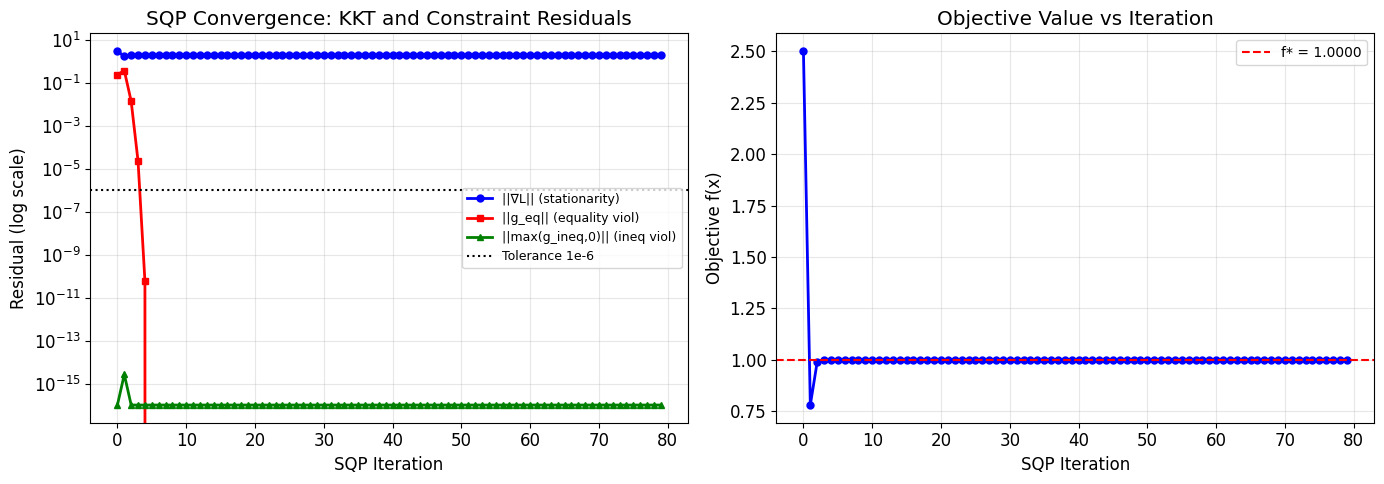

In [8]:
# Convergence plots
iters  = [h['iter']     for h in hist_sqp]
kkts   = [h['kkt']      for h in hist_sqp]
eq_vs  = [h['eq_viol']  for h in hist_sqp]
iq_vs  = [h['ineq_viol'] for h in hist_sqp]
fs     = [h['f']        for h in hist_sqp]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(iters, kkts,  'b-o', markersize=5, linewidth=2, label='||∇L|| (stationarity)')
ax.semilogy(iters, eq_vs, 'r-s', markersize=5, linewidth=2, label='||g_eq|| (equality viol)')
ax.semilogy(iters, [max(v, 1e-16) for v in iq_vs],
            'g-^', markersize=5, linewidth=2, label='||max(g_ineq,0)|| (ineq viol)')
ax.axhline(1e-6, color='k', linestyle=':', linewidth=1.5, label='Tolerance 1e-6')
ax.set_xlabel('SQP Iteration')
ax.set_ylabel('Residual (log scale)')
ax.set_title('SQP Convergence: KKT and Constraint Residuals')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(iters, fs, 'b-o', markersize=5, linewidth=2)
ax2.axhline(ref.fun, color='r', linestyle='--', linewidth=1.5, label=f'f* = {ref.fun:.4f}')
ax2.set_xlabel('SQP Iteration')
ax2.set_ylabel('Objective f(x)')
ax2.set_title('Objective Value vs Iteration')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

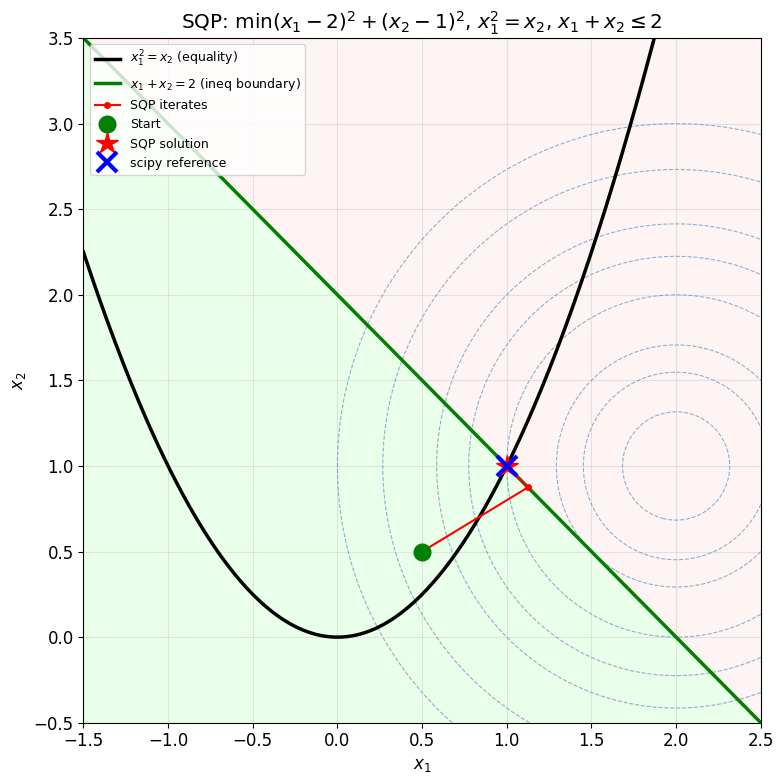

In [9]:
# Visualize the problem and SQP trajectory
fig, ax = plt.subplots(figsize=(8, 8))

x_v = np.linspace(-1.5, 2.5, 400)
y_v = np.linspace(-0.5, 3.5, 400)
Xg, Yg = np.meshgrid(x_v, y_v)
Zf = (Xg-2)**2 + (Yg-1)**2

# Feasible region: x1^2 - x2 = 0 AND x1+x2 <= 2
# (feasible set is the parabola x2=x1^2 with x1+x1^2 <= 2)

# Shade ineq feasible region
ineq_feas = (Xg + Yg <= 2)
ax.contourf(Xg, Yg, np.where(ineq_feas, 1.0, np.nan),
            levels=[0.5, 1.5], colors=['#ccffcc'], alpha=0.4)
ax.contourf(Xg, Yg, np.where(~ineq_feas, 1.0, np.nan),
            levels=[0.5, 1.5], colors=['#ffcccc'], alpha=0.2)

# Objective contours
ax.contour(Xg, Yg, Zf, levels=[0.1, 0.3, 0.5, 1, 1.5, 2, 3, 4],
           colors='steelblue', linewidths=0.8, linestyles='dashed', alpha=0.6)

# Equality constraint parabola x2 = x1^2
t = np.linspace(-1.5, 2.0, 300)
ax.plot(t, t**2, 'k-', linewidth=2.5, label=r'$x_1^2 = x_2$ (equality)')

# Inequality constraint line
x_line = np.linspace(-1.5, 2.5, 100)
ax.plot(x_line, 2-x_line, 'g-', linewidth=2.5, label=r'$x_1+x_2=2$ (ineq boundary)')

# SQP trajectory
xs_traj = np.array([h['x'] for h in hist_sqp])
ax.plot(xs_traj[:,0], xs_traj[:,1], 'r.-', markersize=8, linewidth=1.5,
        label='SQP iterates', zorder=4)
ax.plot(*xs_traj[0], 'go', markersize=12, zorder=5, label='Start')
ax.plot(*x_sqp, 'r*', markersize=16, zorder=6, label=f'SQP solution')
ax.plot(*ref.x, 'bx', markersize=14, markeredgewidth=3, zorder=6, label='scipy reference')

ax.set_xlim(-1.5, 2.5)
ax.set_ylim(-0.5, 3.5)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title(r'SQP: $\min(x_1-2)^2+(x_2-1)^2$, $x_1^2=x_2$, $x_1+x_2 \leq 2$')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Quadratic Convergence Near the Solution

SQP with the exact Lagrangian Hessian converges **quadratically** near the solution.
With BFGS, convergence is **superlinear**. Let's measure the convergence rate.

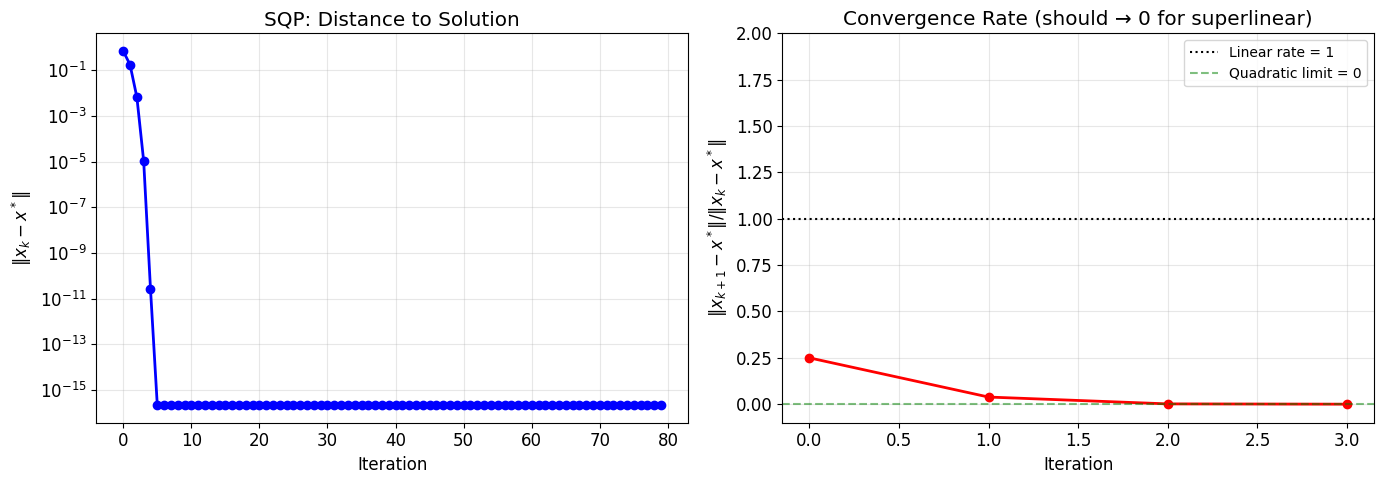

Convergence history (last 10 iterations):
 Iter      ||x-x*||      Rate
   70    2.2204e-16         -
   71    2.2204e-16         -
   72    2.2204e-16         -
   73    2.2204e-16         -
   74    2.2204e-16         -
   75    2.2204e-16         -
   76    2.2204e-16         -
   77    2.2204e-16         -
   78    2.2204e-16         -
   79    2.2204e-16         -


In [10]:
x_opt = ref.x
errors = [np.linalg.norm(h['x'] - x_opt) for h in hist_sqp]

# Compute convergence rates: ratio ||x_{k+1}-x*|| / ||x_k-x*||
rates = []
for k in range(1, len(errors)):
    if errors[k-1] > 1e-12 and errors[k] > 1e-12:
        rates.append(errors[k] / errors[k-1])
    else:
        rates.append(None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(range(len(errors)), errors, 'b-o', markersize=6, linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|x_k - x^*\|$')
ax.set_title('SQP: Distance to Solution')
ax.grid(True, alpha=0.3)

ax2 = axes[1]
valid_rates = [(i, r) for i,r in enumerate(rates) if r is not None and r < 5]
if valid_rates:
    rate_iters = [i for i,_ in valid_rates]
    rate_vals  = [r for _,r in valid_rates]
    ax2.plot(rate_iters, rate_vals, 'r-o', markersize=6, linewidth=2)
    ax2.axhline(1.0, color='k', linestyle=':', label='Linear rate = 1')
    ax2.axhline(0.0, color='g', linestyle='--', alpha=0.5, label='Quadratic limit = 0')
ax2.set_xlabel('Iteration')
ax2.set_ylabel(r'$\|x_{k+1}-x^*\| / \|x_k-x^*\|$')
ax2.set_title('Convergence Rate (should → 0 for superlinear)')
ax2.set_ylim(-0.1, 2.0)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print last few errors
print("Convergence history (last 10 iterations):")
print(f"{'Iter':>5}  {'||x-x*||':>12}  {'Rate':>8}")
n_show = min(10, len(errors))
for i in range(len(errors)-n_show, len(errors)):
    rate_str = f"{rates[i-1]:.4f}" if i > 0 and rates[i-1] is not None else "  -"
    print(f"{i:>5}  {errors[i]:>12.4e}  {rate_str:>8}")

## Connection to ripopt

SQP is ripopt's **last-resort fallback** (`src/sqp.rs`). It triggers when IPM, L-BFGS, and
Augmented Lagrangian all fail to converge.

**Why IPM is the primary solver (not SQP):**

| Property | SQP | IPM (ripopt primary) |
|---|---|---|
| Global convergence | Depends on merit function | Robust via barrier |
| Degenerate points | Can fail (LICQ needed) | Handles degeneracy better |
| Per-iteration cost | $O(n^3)$ if exact Hessian | $O((n+m)^3)$ |
| Warm start | Good (reuse $B_k$) | Less natural |
| Near solution | Quadratic (fast!) | Newton is also quadratic |

**SQP and IPM are complementary:**
- IPM is better **globally** (the barrier function provides natural constraint enforcement)
- SQP is more **predictable near degenerate points** (active set handles rank-deficient Jacobians)

**What the full ripopt fallback chain looks like in practice:**
1. **IPM** solves ~78% of CUTEst problems (78.3%) directly
2. **NE→LS reformulation** catches nonlinear equation systems (m ≥ n, f≡0)
3. **Slack formulation** (explicit slacks) handles restoration cycling problems
4. **Augmented Lagrangian** for equality-only problems where IPM stalls
5. **SQP** for remaining degenerate cases

The theoretical foundation of this entire pipeline — Taylor expansion, Newton's method,
KKT conditions, and the penalty/Lagrangian framework — is exactly what you've built in this tutorial series.

In [11]:
# Summary of all 5 notebooks
print("=" * 65)
print("Tutorial Series Summary: NLP to ripopt")
print("=" * 65)
topics = [
    ("01_nlp_intro",                 "NLP problem structure, feasibility, HS071"),
    ("02_unconstrained",             "Gradient descent, Newton, Armijo/Wolfe, L-BFGS"),
    ("03_kkt_conditions",            "Lagrangian, KKT, complementarity, LICQ"),
    ("04_penalty_augmented_lagrangian", "Penalty method, AL, ill-conditioning"),
    ("05_sqp",                        "QP subproblems, active set, BFGS, merit function"),
]
for nb, desc in topics:
    print(f"  {nb:<40} {desc}")
print()
print("The algorithms above are the building blocks of:")
print("  - Interior Point Method (Notebooks 02-03 + barrier terms)")
print("  - ripopt: Rust IPM with SQP/AL/L-BFGS fallback chain")
print("  - All major NLP solvers (Ipopt, SNOPT, KNITRO, CONOPT)")

Tutorial Series Summary: NLP to ripopt
  01_nlp_intro                             NLP problem structure, feasibility, HS071
  02_unconstrained                         Gradient descent, Newton, Armijo/Wolfe, L-BFGS
  03_kkt_conditions                        Lagrangian, KKT, complementarity, LICQ
  04_penalty_augmented_lagrangian          Penalty method, AL, ill-conditioning
  05_sqp                                   QP subproblems, active set, BFGS, merit function

The algorithms above are the building blocks of:
  - Interior Point Method (Notebooks 02-03 + barrier terms)
  - ripopt: Rust IPM with SQP/AL/L-BFGS fallback chain
  - All major NLP solvers (Ipopt, SNOPT, KNITRO, CONOPT)
